In [2]:
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
insurance_data = pd.read_csv('dataset/insurance.csv')

insurance_data.sample(10)

,age,sex,bmi,children,smoker,region,charges
449,35,male,38.600,1,no,southwest,4762.32900
68,40,female,36.190,0,no,southeast,5920.10410
111,55,female,29.700,2,no,southwest,11881.35800
306,28,female,27.500,2,no,southwest,20177.67113
873,43,male,30.100,1,no,southwest,6849.02600
891,36,female,29.040,4,no,southeast,7243.81360
1125,63,female,25.080,0,no,northwest,14254.60820
991,38,female,27.835,2,no,northeast,7144.86265
403,49,male,32.300,3,no,northwest,10269.46000
1270,26,male,33.915,1,no,northwest,3292.52985


In [5]:
insurance_data.shape

(1338, 7)

In [6]:
insurance_data_correlation = insurance_data.corr()

insurance_data_correlation

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<AxesSubplot:>

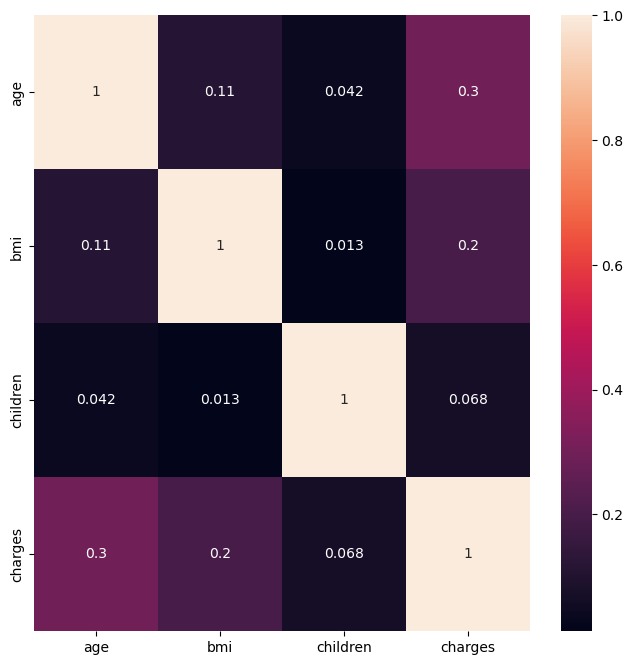

In [7]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(insurance_data_correlation, annot=True)

In [8]:
from sklearn import preprocessing

label_encoding = preprocessing.LabelEncoder()

In [9]:
insurance_data['region'] = label_encoding.fit_transform(insurance_data['region'].astype(str))

In [10]:
label_encoding.classes_

array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)

In [11]:
insurance_data = pd.get_dummies(insurance_data, columns=['sex', 'smoker'])

insurance_data.sample(10)

,age,bmi,children,region,charges,sex_female,sex_male,smoker_no,smoker_yes
709,36,27.740,0,0,5469.00660,1,0,1,0
779,53,28.880,0,1,9869.81020,0,1,1,0
865,40,29.900,2,3,6600.36100,0,1,1,0
515,58,35.700,0,3,11362.75500,0,1,1,0
755,31,27.645,2,0,5031.26955,0,1,1,0
1275,57,23.700,0,3,10959.33000,0,1,1,0
1302,25,20.800,1,3,3208.78700,1,0,1,0
570,31,29.100,0,3,3761.29200,1,0,1,0
39,60,39.900,0,3,48173.36100,0,1,0,1
634,51,39.700,1,3,9391.34600,0,1,1,0


In [16]:
insurance_data.to_csv('processed_dataset/insurance_processed.csv', index=False)

In [17]:
!ls processed_dataset

insurance_processed.csv  PimaIndians_processed.csv


In [20]:
insurance_data = pd.read_csv('processed_dataset/insurance_processed.csv')

insurance_data.sample(10)

,age,bmi,children,region,charges,sex_female,sex_male,smoker_no,smoker_yes
828,41,30.780,3,0,39597.40720,0,1,0,1
1309,41,32.200,2,3,6875.96100,0,1,1,0
1068,63,21.660,1,1,14349.85440,0,1,1,0
1061,57,27.940,1,2,11554.22360,0,1,1,0
764,45,25.175,2,0,9095.06825,1,0,1,0
1288,20,39.400,2,3,38344.56600,0,1,0,1
212,24,28.500,2,1,3537.70300,0,1,1,0
210,20,33.000,1,3,1980.07000,0,1,1,0
1177,40,27.400,1,3,6496.88600,1,0,1,0
76,29,29.590,1,2,3947.41310,1,0,1,0


In [21]:
X = insurance_data.drop('charges', axis=1)

Y = insurance_data['charges']

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [23]:
x_train.shape, y_train.shape

((1070, 8), (1070,))

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

In [25]:
bag_reg = BaggingRegressor(DecisionTreeRegressor(),
                           n_estimators=500,
                           bootstrap=True,
                           max_samples=0.8,
                           n_jobs=1,
                           oob_score=True)

bag_reg.fit(x_train, y_train)

BaggingRegressor(base_estimator=DecisionTreeRegressor(), max_samples=0.8,
                 n_estimators=500, n_jobs=1, oob_score=True)

In [27]:
bag_reg.oob_score_

0.849686155219201

In [28]:
from sklearn.metrics import r2_score

y_pred = bag_reg.predict(x_test)

r2_score(y_test, y_pred)

0.8254487069045425

In [29]:
bag_reg = BaggingRegressor(DecisionTreeRegressor(),
                           n_estimators=500,
                           bootstrap=False,
                           max_samples=0.9,
                           n_jobs=1)

bag_reg.fit(x_train, y_train)

BaggingRegressor(base_estimator=DecisionTreeRegressor(), bootstrap=False,
                 max_samples=0.9, n_estimators=500, n_jobs=1)

In [30]:
y_pred = bag_reg.predict(x_test)

r2_score(y_test, y_pred)

0.8102374556927379